# PEFT Comparison Dashboard
**So sánh LoRA vs Adapters vs Prefix-Tuning**


## 1. Load kết quả từ 3 notebook

In [4]:
import json, os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

INPUT_DIR = "/kaggle/input/models/bohong111/model-lora-prefix-adapters/transformers/default/1"
OUTPUT_DIR = "/kaggle/working/peft_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load 3 sumary 
summaries = []
files = ["lora_summary.json", "adapter_summary.json", "prefix_summary.json"]
names = ["LoRA", "Adapters", "Prefix-Tuning"]

for fname, name in zip(files, names):
    path = os.path.join(INPUT_DIR, fname)
    if os.path.exists(path):
        with open(path) as f:
            s = json.load(f)
        summaries.append(s)
        print(f"Loaded: {fname}")
    else:
        print(f"Chưa có {fname} — chạy notebook {name} trước!")

print(f"\nLoaded {len(summaries)}/3 summaries")
for s in summaries:
    print(f"\n{'='*40}")
    print(json.dumps(s, indent=2))

Loaded: lora_summary.json
Loaded: adapter_summary.json
Loaded: prefix_summary.json

Loaded 3/3 summaries

{
  "method": "LoRA",
  "model_name": "bert-base-uncased",
  "adapter_path": "/kaggle/working/peft_outputs/lora_adapter",
  "trainable_params": 296450,
  "trainable_pct": 0.2700395193203643,
  "best_val_f1": 0.8999758097938318,
  "best_val_acc": 0.9,
  "test_f1": 0.9079531828275352,
  "test_acc": 0.908,
  "training_time_s": 4531.876900672913,
  "peak_mem_gb": 1.544480256
}

{
  "method": "Bottleneck Adapter",
  "model_name": "bert-base-uncased",
  "adapter_path": "/kaggle/working/peft_outputs/bottleneck_adapter",
  "adapter_config": "Pfeiffer, reduction_factor=16, bottleneck_dim=48",
  "trainable_params": 2109308,
  "trainable_pct": 1.8902040860657296,
  "best_val_f1": 0.8953279824456505,
  "best_val_acc": 0.8953333333333333,
  "test_f1": 0.9066397711748635,
  "test_acc": 0.9066666666666666,
  "training_time_s": 4820.9986255168915,
  "peak_mem_gb": 2.454847488
}

{
  "method": "Pre

## 2. Chuẩn bị dữ liệu & Bảng tóm tắt

In [5]:
# Kiểm tra phải có đủ 3 phương pháp (3 file JSON)
assert len(summaries) == 3, "Cần đủ 3 summary! Chạy xong cả 3 notebook trước."

# Lấy tên phương pháp (LoRA, Adapters, Prefix-Tuning)
methods    = [s["method"]           for s in summaries] 
test_accs  = [s["test_acc"]         for s in summaries]              # acc trên tập test 
test_f1s   = [s["test_f1"]          for s in summaries]              # f1 trên tập test
val_accs   = [s["best_val_acc"]     for s in summaries]              # # Lấy tên phương pháp (LoRA, Adapters, Prefix-Tuning)
val_f1s    = [s["best_val_f1"]      for s in summaries]
params     = [s["trainable_params"] for s in summaries]
param_pcts = [s["trainable_pct"]    for s in summaries]
times      = [s["training_time_s"]  for s in summaries]
mems       = [s["peak_mem_gb"]      for s in summaries]

colors = ["#378ADD", "#E8913C", "#2ECC71"]
print("Data ready!")
print(f"{'Method':<20} {'Test Acc':>10} {'Test F1':>10} {'Params%':>10} {'Time(s)':>10} {'Mem(GB)':>10}")
print("-" * 72)
for s in summaries:
    print(f"{s['method']:<20} {s['test_acc']:>10.4f} {s['test_f1']:>10.4f} "
          f"{s['trainable_pct']:>9.3f}% {s['training_time_s']:>10.1f} {s['peak_mem_gb']:>10.2f}")

Data ready!
Method                 Test Acc    Test F1    Params%    Time(s)    Mem(GB)
------------------------------------------------------------------------
LoRA                     0.9080     0.9080     0.270%     4531.9       1.54
Bottleneck Adapter       0.9067     0.9066     1.890%     4821.0       2.45
Prefix-Tuning            0.8987     0.8986     0.337%     4295.1       1.37


## 3. Biểu đồ Accuracy & F1

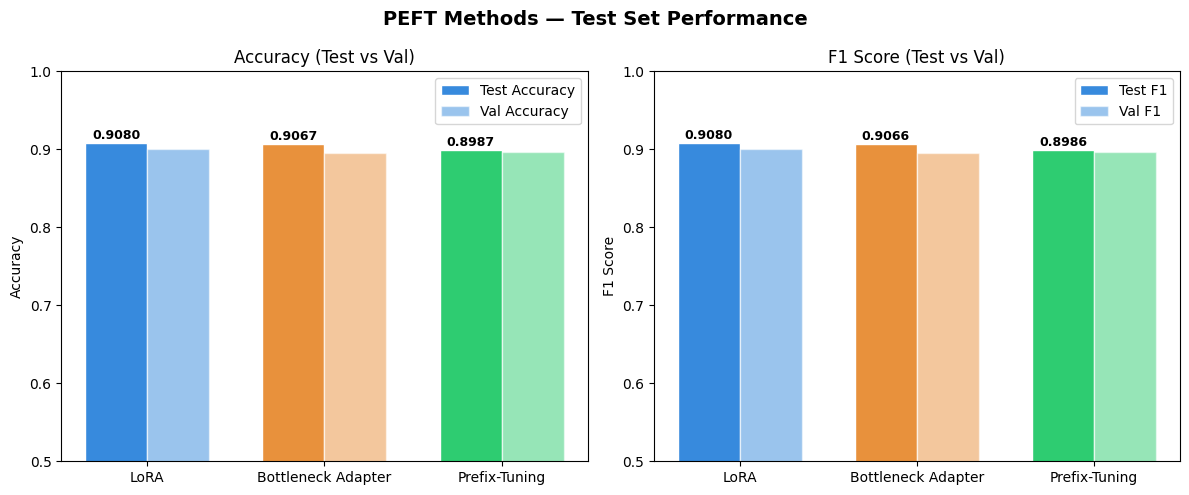

Saved: /kaggle/working/peft_outputs/compare_accuracy_f1.png


In [6]:
# Biểu đồ 1: So sánh Accuracy & F1 (Test Set) 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("PEFT Methods — Test Set Performance", fontsize=14, fontweight="bold")

x = np.arange(len(methods))
width = 0.35

# Biểu đồ Accuracy
bars1 = axes[0].bar(x - width/2, test_accs, width, label="Test Accuracy", color=colors, edgecolor="white")
axes[0].bar(x + width/2, val_accs, width, label="Val Accuracy", color=colors, edgecolor="white", alpha=0.5)
axes[0].set_title("Accuracy (Test vs Val)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Ghi giá trị lên đầu mỗi cột Test Accuracy
for bar, val in zip(bars1, test_accs):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# Biểu đồ F1 Score
bars2 = axes[1].bar(x - width/2, test_f1s, width, label="Test F1", color=colors, edgecolor="white")
# Vẽ cột Validation F1
axes[1].bar(x + width/2, val_f1s, width, label="Val F1", color=colors, edgecolor="white", alpha=0.5)
axes[1].set_title("F1 Score (Test vs Val)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods)
axes[1].set_ylim(0.5, 1.0)
axes[1].set_ylabel("F1 Score")
axes[1].legend()

for bar, val in zip(bars2, test_f1s):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "compare_accuracy_f1.png")
plt.savefig(save_path, dpi=150)
plt.show()
print("Saved:", save_path)

## 4. Biểu đồ Efficiency (Params & Time)

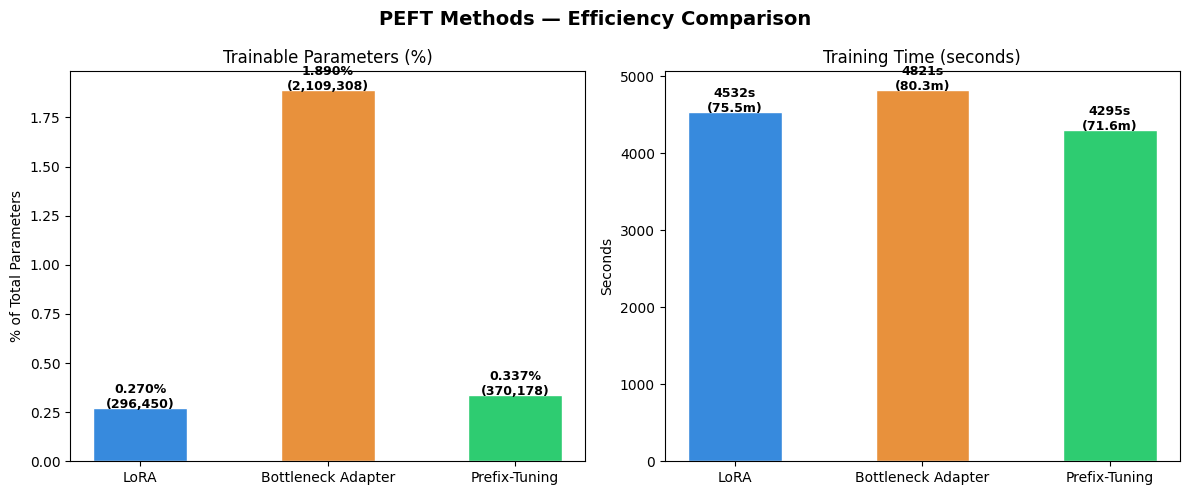

Saved: compare_efficiency.png


In [7]:
# Biểu đồ 2: Trainable Parameters & Training Time 
# So sánh hiệu quả sử dụng tài nguyên của các phương pháp PEFT
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("PEFT Methods — Efficiency Comparison", fontsize=14, fontweight="bold")

# Vẽ biểu đồ cột: % tham số train được
# dùng bao nhiêu % tham số để train, kèm theo số lượng params thực tế
bars = axes[0].bar(methods, param_pcts, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Trainable Parameters (%)")
axes[0].set_ylabel("% of Total Parameters")
for bar, val, p in zip(bars, param_pcts, params):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f"{val:.3f}%\n({p:,})", ha="center", fontsize=9, fontweight="bold")

# Biểu đồ Training Time
# mỗi phương pháp mất bao lâu để train
bars2 = axes[1].bar(methods, times, color=colors, edgecolor="white", width=0.5)
axes[1].set_title("Training Time (seconds)")
axes[1].set_ylabel("Seconds")
for bar, val in zip(bars2, times):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f"{val:.0f}s\n({val/60:.1f}m)", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "compare_efficiency.png"), dpi=150)
plt.show()
print("Saved: compare_efficiency.png")


## 5. Biểu đồ GPU Memory

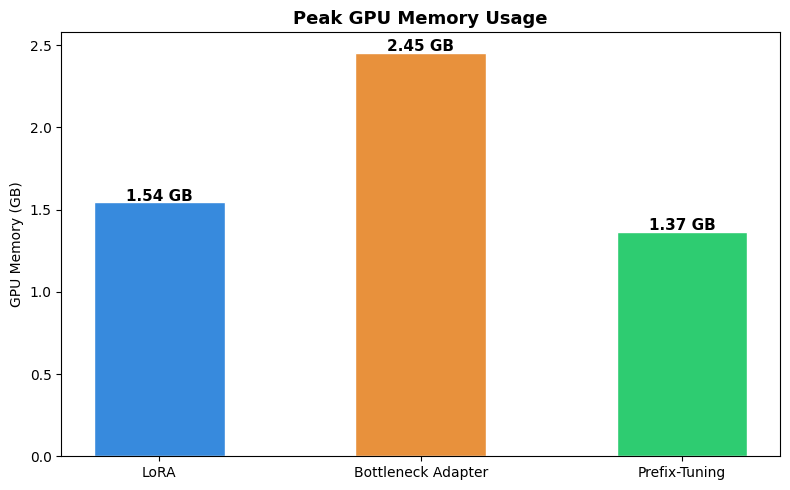

Saved: compare_memory.png


In [8]:
# Biểu đồ 3: GPU Memory Usage 
# Biểu đồ dùng để so sánh mức sử dụng bộ nhớ GPU tối đa giữa các phương pháp PEFT nhằm đánh giá hiệu quả tài nguyên khi huấn luyện
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, mems, color=colors, edgecolor="white", width=0.5)
ax.set_title("Peak GPU Memory Usage", fontsize=13, fontweight="bold")
ax.set_ylabel("GPU Memory (GB)")
for bar, val in zip(bars, mems):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.2f} GB", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "compare_memory.png"), dpi=150)
plt.show()
print("Saved: compare_memory.png")


## 6. Radar Chart — So sánh đa chiều

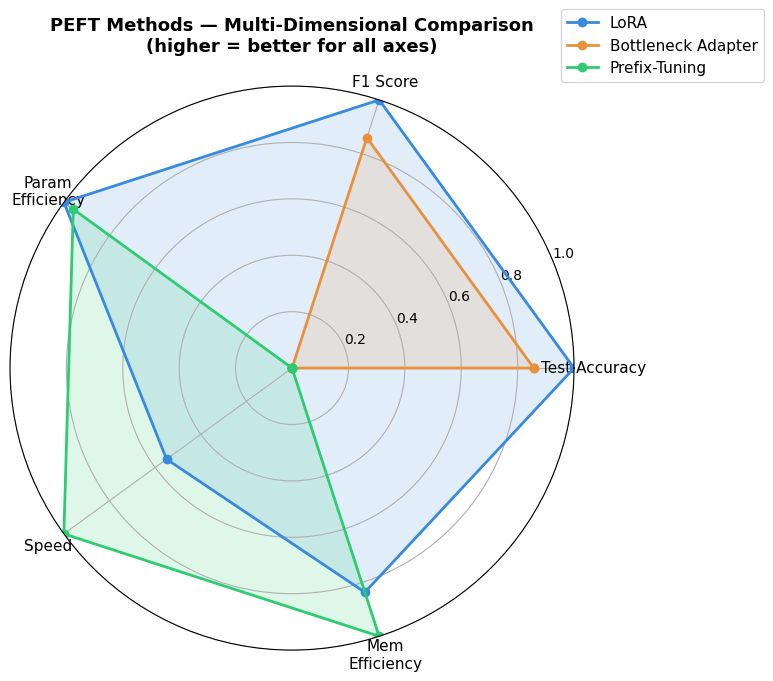

Saved: radar_chart.png


In [10]:
# Biểu đồ 4: Radar Chart — So sánh đa chiều 
# LoRA rất nhẹ: Tối ưu tài nguyên (nhẹ, tiết kiệm) nhưng độ chính xác chưa tốt nhất
# Adapter: Hiệu năng tốt nhất nhưng tốn tài nguyên nhất
# Prefix-Tuning: Cân bằng tốt nhất giữa hiệu năng và tài nguyên
def norm(vals, higher_better=True):
    mn, mx = min(vals), max(vals)
    if mx == mn: return [0.5]*len(vals)
    n = [(v-mn)/(mx-mn) for v in vals]
    return n if higher_better else [1-x for x in n]

categories = ["Test Accuracy", "F1 Score", "Param\nEfficiency", "Speed", "Mem\nEfficiency"]
N = len(categories)
angles = [n/float(N)*2*3.14159 for n in range(N)]
angles += angles[:1]

norm_data = list(zip(
    norm(test_accs,  True),
    norm(test_f1s,   True),
    norm(param_pcts, False),
    norm(times,      False),
    norm(mems,       False),
))

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for i, (s, nd) in enumerate(zip(summaries, norm_data)):
    vals = list(nd) + [nd[0]]
    ax.plot(angles, vals, "o-", linewidth=2, color=colors[i], label=s["method"])
    ax.fill(angles, vals, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_title("PEFT Methods — Multi-Dimensional Comparison\n(higher = better for all axes)",
             size=13, pad=25, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "radar_chart.png"), dpi=150)
plt.show()
print("Saved: radar_chart.png")


## 7. Bảng tổng hợp & Kết luận

In [12]:
# ── Bảng tổng hợp cuối cùng ───────────────────────────────────
print("\n" + "="*80)
print("PEFT COMPARISON SUMMARY — IMDB Sentiment Analysis")
print("="*80)
print(f"{'Metric':<25} {'LoRA':>15} {'Adapters':>15} {'Prefix-Tuning':>15}")
print("-"*70)

rows = [
    ("Test Accuracy",      [f"{s['test_acc']:.4f}"         for s in summaries]),
    ("Test F1",            [f"{s['test_f1']:.4f}"          for s in summaries]),
    ("Val Accuracy",       [f"{s['best_val_acc']:.4f}"     for s in summaries]),
    ("Val F1",             [f"{s['best_val_f1']:.4f}"      for s in summaries]),
    ("Trainable Params",   [f"{s['trainable_params']:,}"   for s in summaries]),
    ("Trainable %",        [f"{s['trainable_pct']:.3f}%"   for s in summaries]),
    ("Training Time",      [f"{s['training_time_s']:.1f}s" for s in summaries]),
    ("Peak GPU Mem",       [f"{s['peak_mem_gb']:.2f} GB"   for s in summaries]),
]

for metric, vals in rows:
    print(f"{metric:<25} {vals[0]:>15} {vals[1]:>15} {vals[2]:>15}")

print("="*80)

# Kết luận tự động
best_acc = summaries[max(range(3), key=lambda i: summaries[i]["test_acc"])]["method"]
best_f1  = summaries[max(range(3), key=lambda i: summaries[i]["test_f1"])]["method"]
best_eff = summaries[min(range(3), key=lambda i: summaries[i]["trainable_pct"])]["method"]
best_spd = summaries[min(range(3), key=lambda i: summaries[i]["training_time_s"])]["method"]
best_mem = summaries[min(range(3), key=lambda i: summaries[i]["peak_mem_gb"])]["method"]

print("\nCONCLUSIONS:")
print(f"  Best Accuracy      : {best_acc}")
print(f"  Best F1 Score      : {best_f1}")
print(f"  Most Param Efficient: {best_eff}")
print(f"  Fastest Training   : {best_spd}")
print(f"  Lowest Memory      : {best_mem}")

# Lưu summary tổng hợp
combined = {
    "task": "Sentiment Analysis",
    "dataset": "IMDB (15k subset)",
    "base_model": "bert-base-uncased",
    "results": summaries,
    "best": {
        "accuracy": best_acc,
        "f1": best_f1,
        "efficiency": best_eff,
        "speed": best_spd,
        "memory": best_mem,
    }
}
with open(os.path.join(OUTPUT_DIR, "combined_summary.json"), "w") as f:
    json.dump(combined, f, indent=2, ensure_ascii=False)
print("\nSaved: combined_summary.json")



PEFT COMPARISON SUMMARY — IMDB Sentiment Analysis
Metric                               LoRA        Adapters   Prefix-Tuning
----------------------------------------------------------------------
Test Accuracy                      0.9080          0.9067          0.8987
Test F1                            0.9080          0.9066          0.8986
Val Accuracy                       0.9000          0.8953          0.8960
Val F1                             0.9000          0.8953          0.8960
Trainable Params                  296,450       2,109,308         370,178
Trainable %                        0.270%          1.890%          0.337%
Training Time                     4531.9s         4821.0s         4295.1s
Peak GPU Mem                      1.54 GB         2.45 GB         1.37 GB

CONCLUSIONS:
  Best Accuracy      : LoRA
  Best F1 Score      : LoRA
  Most Param Efficient: LoRA
  Fastest Training   : Prefix-Tuning
  Lowest Memory      : Prefix-Tuning

Saved: combined_summary.json
